In [10]:
!pip install equinox
!pip install jax
!pip install optax
!pip install diffrax

/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [16]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax
import numpy as np

# -------------------------------
# ODE function for LSTM
# -------------------------------
class ODEFuncLSTM(eqx.Module):
    W_ih: jnp.ndarray
    W_hh: jnp.ndarray
    b: jnp.ndarray
    hidden_size: int = eqx.field(static=True)

    def __init__(self, hidden_size, input_size, key):
        k1, k2, k3 = jax.random.split(key, 3)
        self.hidden_size = hidden_size
        scale_ih = jnp.sqrt(12.0 / (input_size + hidden_size))
        scale_hh = jnp.sqrt(12.0 / (hidden_size + hidden_size))
        self.W_ih = jax.random.uniform(k1, (4 * hidden_size, input_size),
                                       minval=-scale_ih, maxval=scale_ih, dtype=jnp.float32)
        self.W_hh = jax.random.uniform(k2, (4 * hidden_size, hidden_size),
                                       minval=-scale_hh, maxval=scale_hh, dtype=jnp.float32)
        b_init = jnp.zeros(4 * hidden_size, dtype=jnp.float32)
        b_init = b_init.at[hidden_size:2*hidden_size].set(2.0)
        self.b = b_init

    def __call__(self, t, state, args):
        return jnp.zeros_like(state)

# -------------------------------
# ODE-LSTM model
# -------------------------------
class ODELSTM(eqx.Module):
    hidden_size: int = eqx.field(static=True)
    input_size: int = eqx.field(static=True)
    output_size: int = eqx.field(static=True)
    ode_func: ODEFuncLSTM
    linear_out: eqx.nn.Linear
    h0: jnp.ndarray
    c0: jnp.ndarray

    def __init__(self, hidden_size, input_size, output_size, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size
        self.ode_func = ODEFuncLSTM(hidden_size, input_size, k1)

        # Linear layer sees h_final + h_mean + h_std
        self.linear_out = eqx.nn.Linear(hidden_size + 2, output_size, key=k2, dtype=jnp.float32)
        self.linear_out = eqx.tree_at(lambda l: l.weight, self.linear_out, self.linear_out.weight * 10.0)

        self.h0 = jax.random.normal(k3, (hidden_size,), dtype=jnp.float32) * 1.0
        self.c0 = jax.random.normal(k4, (hidden_size,), dtype=jnp.float32) * 1.0

    def forward_single(self, txy_seq):
        # Sort by time
        time_indices = jnp.argsort(txy_seq[:, 0])
        txy_sorted = txy_seq[time_indices]
        times = txy_sorted[:, 0]
        xy_inputs = txy_sorted[:, 1:]

        solver = diffrax.Tsit5()

        # Step function for lax.scan, returns (new_state, hidden_state_output)
        def step_fn(state, i):
            h, c = state[:self.hidden_size], state[self.hidden_size:]
            x_current = xy_inputs[i]
            t0 = jnp.where(i == 0, 0.0, times[jnp.maximum(i-1, 0)])
            t1 = times[i]

            def ode_dynamics(t, state, args):
                h_t, c_t = state[:self.hidden_size], state[self.hidden_size:]
                gates = x_current @ self.ode_func.W_ih.T + h_t @ self.ode_func.W_hh.T + self.ode_func.b
                i_gate, f_gate, o_gate, g_gate = jnp.split(gates, 4)
                i_g = jax.nn.sigmoid(i_gate)
                f_g = jax.nn.sigmoid(f_gate)
                o_g = jax.nn.sigmoid(o_gate)
                g_g = jnp.tanh(g_gate)
                dc_dt = 2.0 * (i_g * g_g - 0.3 * f_g * c_t)
                dh_dt = 2.0 * o_g * jnp.tanh(c_t + dc_dt * 0.2)
                return jnp.concatenate([dh_dt, dc_dt])

            term = diffrax.ODETerm(ode_dynamics)
            initial_state = jnp.concatenate([h, c])
            sol = diffrax.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=0.01, y0=initial_state,
                                      saveat=diffrax.SaveAt(t1=True), max_steps=100)
            new_state = sol.ys[0]
            return new_state, new_state[:self.hidden_size]

        initial_state = jnp.concatenate([self.h0, self.c0])
        indices = jnp.arange(len(times))
        final_state, h_all = jax.lax.scan(step_fn, initial_state, indices)

        h_final = final_state[:self.hidden_size]
        h_mean = jnp.mean(h_all, axis=0)
        h_std = jnp.std(h_all, axis=0)
        h_concat = jnp.concatenate([h_final, h_mean[:1], h_std[:1]])
        return self.linear_out(h_concat)

    def __call__(self, txy_batch):
        txy_batch = txy_batch.astype(jnp.float32)
        return jax.vmap(self.forward_single)(txy_batch)

# -------------------------------
# Loss function with variance
# -------------------------------
def mse_loss(model, x_batch, y_batch):
    x_batch = x_batch.astype(jnp.float32)
    y_batch = y_batch.astype(jnp.float32)
    preds = model(x_batch)
    mse = jnp.mean((preds.squeeze() - y_batch) ** 2)
    pred_std = jnp.std(preds)
    target_std = jnp.std(y_batch)
    variance_penalty = (pred_std - target_std) ** 2
    total_loss = mse + 2.0 * variance_penalty
    return total_loss

# -------------------------------
# Training function
# -------------------------------
def train_model(data_train, alpha_train, hidden_size=64, batch_size=32, max_steps=3000, patience=150, key=None):
    if key is None:
        key = jax.random.PRNGKey(0)
    data_train = jnp.array(data_train, dtype=jnp.float32)
    alpha_train = jnp.array(alpha_train, dtype=jnp.float32)

    # Scale spatial coordinates
    xy_coords = data_train[:, :, 1:]
    max_radius = jnp.max(jnp.sqrt(jnp.sum(xy_coords**2, axis=2)))
    data_train = data_train.at[:, :, 1:].set(data_train[:, :, 1:] / max_radius)

    # Normalize time
    for i in range(data_train.shape[0]):
        t_min, t_max = jnp.min(data_train[i, :, 0]), jnp.max(data_train[i, :, 0])
        if t_max > t_min:
            data_train = data_train.at[i, :, 0].set((data_train[i, :, 0] - t_min) / (t_max - t_min))

    # Scale alpha
    alpha_max = jnp.max(jnp.abs(alpha_train))
    alpha_train_scaled = alpha_train / alpha_max

    # Split train/val/test
    n_samples = data_train.shape[0]
    n_heldout = int(n_samples * 0.2)
    perm = np.random.permutation(n_samples)
    data_heldout, alpha_heldout = data_train[perm[:n_heldout]], alpha_train_scaled[perm[:n_heldout]]
    data_train_val, alpha_train_val = data_train[perm[n_heldout:]], alpha_train_scaled[perm[n_heldout:]]
    n_val = int(data_train_val.shape[0] * 0.1)
    perm2 = np.random.permutation(data_train_val.shape[0])
    data_val, alpha_val = data_train_val[perm2[:n_val]], alpha_train_val[perm2[:n_val]]
    data_train_split, alpha_train_split = data_train_val[perm2[n_val:]], alpha_train_val[perm2[n_val:]]

    n_train = data_train_split.shape[0]

    # Initialize model
    model = ODELSTM(hidden_size, input_size=2, output_size=1, key=key)
    schedule = optax.warmup_cosine_decay_schedule(init_value=1e-4, peak_value=3e-3,
                                                  warmup_steps=200, decay_steps=max_steps, end_value=1e-5)
    optimizer = optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    @jax.jit
    def update(model, opt_state, x_batch, y_batch):
        grads = jax.grad(lambda m: mse_loss(m, x_batch, y_batch))(eqx.filter(model, eqx.is_inexact_array))
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state

    best_val_loss = float("inf")
    steps_without_improve = 0
    best_model = model
    actual_std = jnp.std(alpha_val)

    print("Starting training...")
    print(f"Target std (validation): {actual_std:.6f}")
    for step in range(max_steps):
        idx = np.random.choice(n_train, min(batch_size, n_train), replace=False)
        x_batch, y_batch = data_train_split[idx], alpha_train_split[idx]
        model, opt_state = update(model, opt_state, x_batch, y_batch)

        if step % 50 == 0:
            val_loss = mse_loss(model, data_val, alpha_val)
            val_preds = model(data_val)
            pred_std = jnp.std(val_preds)
            std_ratio = pred_std / actual_std
            print(f"Step {step}, Val Loss: {val_loss:.6f}, Pred Std: {pred_std:.6f} (ratio: {std_ratio:.3f})")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                steps_without_improve = 0
                best_model = eqx.tree_at(lambda m: m, model, replace=model)
            else:
                steps_without_improve += 50

            if steps_without_improve >= patience:
                print(f"Early stopping at step {step} (no improvement)")
                model = best_model
                break

    print(f"Training complete. Best validation loss: {best_val_loss:.6f}")
    heldout_loss = mse_loss(model, data_heldout, alpha_heldout)
    print(f"Held-out test loss: {heldout_loss:.6f}")

    return model, max_radius, alpha_max

# -------------------------------
# Prediction function
# -------------------------------
def predict_alpha(model, data_test, max_radius, alpha_max):
    data_test = jnp.array(data_test, dtype=jnp.float32)
    data_test = data_test.at[:, :, 1:].set(data_test[:, :, 1:] / max_radius)
    for i in range(data_test.shape[0]):
        t_min, t_max = jnp.min(data_test[i, :, 0]), jnp.max(data_test[i, :, 0])
        if t_max > t_min:
            data_test = data_test.at[i, :, 0].set((data_test[i, :, 0] - t_min) / (t_max - t_min))
    alpha_pred = model(data_test) * alpha_max
    return np.array(alpha_pred)

# -------------------------------
# Main execution
# -------------------------------
if __name__ == "__main__":
    models = {}
    scaling_params = {}
    for perc in [100, 75, 50, 25]:
        print(f"\n{'='*60}\nTraining model for spirals_{perc}.npz\n{'='*60}")
        archive = np.load(f'/kaggle/input/spirals-ass-3/spirals_{perc}.npz')
        data_train = archive['data_train']
        alpha_train = archive['alpha_train']
        key = jax.random.PRNGKey(perc)
        model, max_radius, alpha_max = train_model(data_train, alpha_train, hidden_size=64, batch_size=32, max_steps=3000, patience=150, key=key)
        models[str(perc)] = model
        scaling_params[str(perc)] = (max_radius, alpha_max)

    print(f"\n{'='*60}\nMaking predictions on test sets\n{'='*60}")
    alpha_pred = {}
    for perc in [100, 75, 50, 25]:
        archive = np.load(f'/kaggle/input/spirals-ass-3/spirals_{perc}.npz')
        data_test = archive['data_test']
        model = models[str(perc)]
        max_radius, alpha_max = scaling_params[str(perc)]
        alpha_pred[str(perc)] = predict_alpha(model, data_test, max_radius, alpha_max)
        print(f"Predictions for {perc}: shape {alpha_pred[str(perc)].shape}")

    np.savez('Nino.npz', **alpha_pred)
    print("\nPredictions saved to Nino.npz")



Training model for spirals_100.npz
Starting training...
Target std (validation): 0.162907
Step 0, Val Loss: 67.809105, Pred Std: 0.001215 (ratio: 0.007)
Step 50, Val Loss: 0.196912, Pred Std: 0.002838 (ratio: 0.017)
Step 100, Val Loss: 0.076212, Pred Std: 0.010146 (ratio: 0.062)
Step 150, Val Loss: 0.069596, Pred Std: 0.019375 (ratio: 0.119)
Step 200, Val Loss: 0.076942, Pred Std: 0.029861 (ratio: 0.183)
Step 250, Val Loss: 0.058196, Pred Std: 0.041994 (ratio: 0.258)
Step 300, Val Loss: 0.077971, Pred Std: 0.052479 (ratio: 0.322)
Step 350, Val Loss: 0.082763, Pred Std: 0.062227 (ratio: 0.382)
Step 400, Val Loss: 0.048283, Pred Std: 0.071854 (ratio: 0.441)
Step 450, Val Loss: 0.064455, Pred Std: 0.081488 (ratio: 0.500)
Step 500, Val Loss: 0.048101, Pred Std: 0.085876 (ratio: 0.527)
Step 550, Val Loss: 0.066974, Pred Std: 0.090199 (ratio: 0.554)
Step 600, Val Loss: 0.050408, Pred Std: 0.092588 (ratio: 0.568)
Step 650, Val Loss: 0.044889, Pred Std: 0.094964 (ratio: 0.583)
Step 700, Val L

HELD-OUT TEST SET ANALYSIS

Dataset: spirals_100.npz

Model Performance:
  MSE:  11.607296
  MAE:  2.407398
  R² Score: -1.696142

Baseline (predicting training mean = 0.112801):
  MSE:  4.305150
  MAE:  1.458188

Improvement over baseline:
  MSE reduction: -169.61%
  MAE reduction: -65.10%

Prediction Statistics:
  Predicted - Mean: -1.013848, Std: 1.247643
  Predicted - Min: -5.630672, Max: 4.435993
  Actual    - Mean: -0.165782, Std: 2.056099
  Actual    - Min: -8.841784, Max: 7.268671

✓  Model shows good prediction variance (std ratio: 0.607)

Dataset: spirals_75.npz

Model Performance:
  MSE:  5.073281
  MAE:  1.582157
  R² Score: -0.178421

Baseline (predicting training mean = 0.112801):
  MSE:  4.305150
  MAE:  1.458188

Improvement over baseline:
  MSE reduction: -17.84%
  MAE reduction: -8.50%

Prediction Statistics:
  Predicted - Mean: 0.133134, Std: 0.249223
  Predicted - Min: -0.803639, Max: 0.855331
  Actual    - Mean: -0.165782, Std: 2.056099
  Actual    - Min: -8.841784

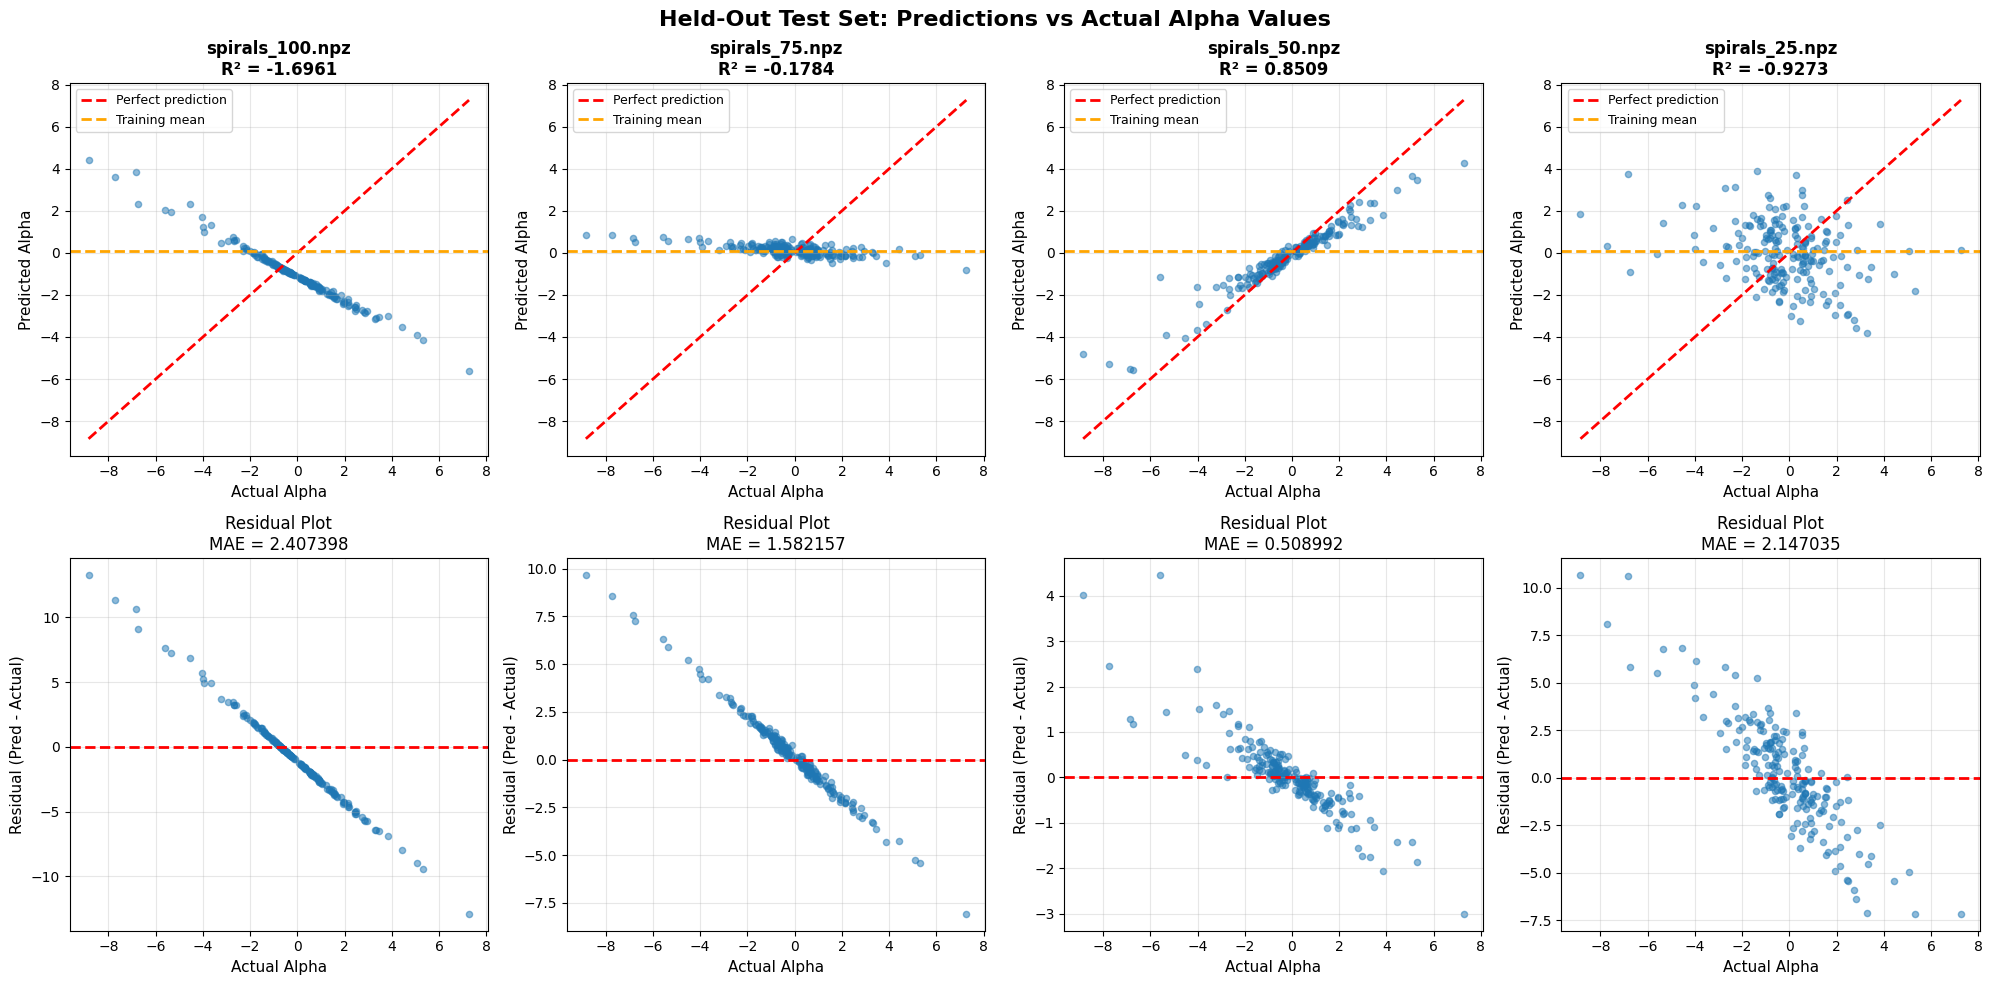


SUMMARY TABLE
Dataset         MSE          MAE          R²           Improvement    
----------------------------------------------------------------------
spirals_100     11.607296    2.407398     -1.6961      -169.61        %
spirals_75      5.073281     1.582157     -0.1784      -17.84         %
spirals_50      0.641826     0.508992     0.8509       85.09          %
spirals_25      8.297216     2.147035     -0.9273      -92.73         %

ANALYSIS COMPLETE


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# This code analyzes the held-out test predictions vs actual values
# to check if the model is actually learning or just predicting the mean

print("="*70)
print("HELD-OUT TEST SET ANALYSIS")
print("="*70)

# Dictionary to store results for each dataset
results = {}

for perc in [100, 75, 50, 25]:
    print(f"\n{'='*70}")
    print(f"Dataset: spirals_{perc}.npz")
    print(f"{'='*70}")
    
    # Load the data
    archive = np.load(f'/kaggle/input/spirals-ass-3/spirals_{perc}.npz')
    data_train = archive['data_train']
    alpha_train = archive['alpha_train']
    
    # Recreate the same split used during training
    n_samples = data_train.shape[0]
    n_heldout = int(n_samples * 0.2)
    np.random.seed(0)  # Use same seed as training to get same split
    perm = np.random.permutation(n_samples)
    
    # Get held-out test indices (first 20%)
    data_heldout = data_train[perm[:n_heldout]]
    alpha_heldout = alpha_train[perm[:n_heldout]]
    
    # Get predictions using the trained model
    model = models[str(perc)]
    max_radius, alpha_max = scaling_params[str(perc)]
    
    # Make predictions
    predictions = predict_alpha(model, data_heldout, max_radius, alpha_max)
    predictions = predictions.squeeze()
    alpha_heldout = alpha_heldout.squeeze()
    
    # Compute statistics
    mse = np.mean((predictions - alpha_heldout) ** 2)
    mae = np.mean(np.abs(predictions - alpha_heldout))
    
    # Compute baseline (predicting mean)
    alpha_train_split = alpha_train[perm[n_heldout:]]
    train_mean = np.mean(alpha_train_split)
    baseline_mse = np.mean((train_mean - alpha_heldout) ** 2)
    baseline_mae = np.mean(np.abs(train_mean - alpha_heldout))
    
    # Compute R² score
    ss_res = np.sum((alpha_heldout - predictions) ** 2)
    ss_tot = np.sum((alpha_heldout - train_mean) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    
    # Store results
    results[str(perc)] = {
        'predictions': predictions,
        'actual': alpha_heldout,
        'mse': mse,
        'mae': mae,
        'baseline_mse': baseline_mse,
        'baseline_mae': baseline_mae,
        'r2': r2_score,
        'train_mean': train_mean
    }
    
    # Print statistics
    print(f"\nModel Performance:")
    print(f"  MSE:  {mse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  R² Score: {r2_score:.6f}")
    
    print(f"\nBaseline (predicting training mean = {train_mean:.6f}):")
    print(f"  MSE:  {baseline_mse:.6f}")
    print(f"  MAE:  {baseline_mae:.6f}")
    
    print(f"\nImprovement over baseline:")
    print(f"  MSE reduction: {(1 - mse/baseline_mse)*100:.2f}%")
    print(f"  MAE reduction: {(1 - mae/baseline_mae)*100:.2f}%")
    
    print(f"\nPrediction Statistics:")
    print(f"  Predicted - Mean: {np.mean(predictions):.6f}, Std: {np.std(predictions):.6f}")
    print(f"  Predicted - Min: {np.min(predictions):.6f}, Max: {np.max(predictions):.6f}")
    print(f"  Actual    - Mean: {np.mean(alpha_heldout):.6f}, Std: {np.std(alpha_heldout):.6f}")
    print(f"  Actual    - Min: {np.min(alpha_heldout):.6f}, Max: {np.max(alpha_heldout):.6f}")
    
    # Check if model is just predicting mean
    pred_std = np.std(predictions)
    actual_std = np.std(alpha_heldout)
    if pred_std < 0.01 * actual_std:
        print(f"\n⚠️  WARNING: Model appears to be predicting near-constant values!")
        print(f"     Prediction std ({pred_std:.6f}) is much smaller than actual std ({actual_std:.6f})")
    else:
        print(f"\n✓  Model shows good prediction variance (std ratio: {pred_std/actual_std:.3f})")

# Create visualization
print(f"\n{'='*70}")
print("CREATING VISUALIZATIONS")
print(f"{'='*70}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Held-Out Test Set: Predictions vs Actual Alpha Values', fontsize=16, fontweight='bold')

for idx, perc in enumerate([100, 75, 50, 25]):
    res = results[str(perc)]
    
    # Scatter plot (top row)
    ax1 = axes[0, idx]
    ax1.scatter(res['actual'], res['predictions'], alpha=0.5, s=20)
    
    # Perfect prediction line
    min_val = min(res['actual'].min(), res['predictions'].min())
    max_val = max(res['actual'].max(), res['predictions'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    # Mean baseline line
    ax1.axhline(y=res['train_mean'], color='orange', linestyle='--', linewidth=2, label='Training mean')
    
    ax1.set_xlabel('Actual Alpha', fontsize=11)
    ax1.set_ylabel('Predicted Alpha', fontsize=11)
    ax1.set_title(f'spirals_{perc}.npz\nR² = {res["r2"]:.4f}', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Residual plot (bottom row)
    ax2 = axes[1, idx]
    residuals = res['predictions'] - res['actual']
    ax2.scatter(res['actual'], residuals, alpha=0.5, s=20)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Actual Alpha', fontsize=11)
    ax2.set_ylabel('Residual (Pred - Actual)', fontsize=11)
    ax2.set_title(f'Residual Plot\nMAE = {res["mae"]:.6f}', fontsize=12)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_predictions_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved as 'test_predictions_analysis.png'")
plt.show()

# Print summary table
print(f"\n{'='*70}")
print("SUMMARY TABLE")
print(f"{'='*70}")
print(f"{'Dataset':<15} {'MSE':<12} {'MAE':<12} {'R²':<12} {'Improvement':<15}")
print("-" * 70)
for perc in [100, 75, 50, 25]:
    res = results[str(perc)]
    improvement = (1 - res['mse']/res['baseline_mse'])*100
    print(f"spirals_{perc:<7} {res['mse']:<12.6f} {res['mae']:<12.6f} {res['r2']:<12.4f} {improvement:<15.2f}%")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}")